# ***Importing Libraries***

In [ ]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report,roc_auc_score,roc_curve
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


# ***Loading Dataset***

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ict/House_Pricing.csv")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [ ]:
# Displaying last 5 rows

df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,Fair,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


In [ ]:
# Shape of the data

df.shape

(21613, 21)

In [ ]:
# Describing data

df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
# Datatypes
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [ ]:
target_data = df["Sale Price"]


# Extracting target data's name
target = target_data.name

In [ ]:
# Convert to datetime format
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'], format='%d %B %Y')

# Extract only the year
df['Sale_Year'] = df['Date House was Sold'].dt.year

# Drop the original date column
df = df.drop(columns=['Date House was Sold'])

In [ ]:
# Drop the column in-place
df = df.drop(columns=['No of Times Visited','ID'])

# **Numerical Data Handling**

In [ ]:
# Selecting numerical columns

df_numerical = df.select_dtypes(exclude=["object"])

df_numerical.head(3)

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year
0,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017
1,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017
2,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016


In [ ]:
# Percentage of missing values of numnerical columns

percentage_of_missing_value = (df_numerical.isna().sum() / len(df)) * 100

percentage_of_missing_value

,0
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Overall Grade,0.000000
Area of the House from Basement (in Sqft),0.013881
Basement Area (in Sqft),0.000000
Age of House (in Years),0.000000


In [ ]:
# Check if  the percentage of missing value < 3%, if yes, remove row
row_drop = percentage_of_missing_value[
                         (percentage_of_missing_value < 3) & (percentage_of_missing_value !=0)
                                      ].index.tolist()

df.dropna(subset=row_drop, inplace=True)

In [ ]:
# Check if the percenage of missing value > 60, if yes, remove column
col_drop = percentage_of_missing_value[percentage_of_missing_value > 60].index.tolist()
df.drop(columns=col_drop, inplace=True, axis=1)

print("Columns dropped", col_drop)
print("Rows dropped", row_drop)

Columns dropped []
Rows dropped ['Sale Price', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)']


In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
km =  KNNImputer(n_neighbors=5)

In [ ]:
imdata = km.fit_transform(df_numerical)

In [ ]:
imdata

array([[2.21900e+05, 3.00000e+00, 1.00000e+00, ..., 1.34000e+03,
        5.65000e+03, 2.01700e+03],
       [5.38000e+05, 3.00000e+00, 2.25000e+00, ..., 1.69000e+03,
        7.63900e+03, 2.01700e+03],
       [1.80000e+05, 2.00000e+00, 1.00000e+00, ..., 2.72000e+03,
        8.06200e+03, 2.01600e+03],
       ...,
       [4.02101e+05, 2.00000e+00, 7.50000e-01, ..., 1.02000e+03,
        2.00700e+03, 2.01700e+03],
       [4.00000e+05, 3.00000e+00, 2.50000e+00, ..., 1.41000e+03,
        1.28700e+03, 2.01600e+03],
       [3.25000e+05, 2.00000e+00, 7.50000e-01, ..., 1.02000e+03,
        1.35700e+03, 2.01700e+03]])

In [ ]:
df_imdata = pd.DataFrame(data=imdata , columns=df_numerical.columns)

In [ ]:
df_imdata.head(2)

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,7.0,1180.0,0.0,63.0,0.0,98178.0,47.5112,-122.257,1340.0,5650.0,2017.0
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,7.0,2170.0,400.0,67.0,1991.0,98125.0,47.7210,-122.319,1690.0,7639.0,2017.0


In [ ]:
df_imdata.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


# **categorical** **columns**

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
df_categories = df.select_dtypes(include=["object"])

In [ ]:
sm =  SimpleImputer(strategy="most_frequent")

In [ ]:
smdata = sm.fit_transform(df_categories)

In [ ]:
smdata

array([['No', 'Fair'],
       ['No', 'Fair'],
       ['No', 'Fair'],
       ...,
       ['No', 'Fair'],
       ['No', 'Fair'],
       ['No', 'Fair']], dtype=object)

In [ ]:
df_smdata = pd.DataFrame(data=imdata , columns=df_numerical.columns)

In [ ]:
df_smdata.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


# **DATA** **ENCODING**

In [ ]:
df.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017
2,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016
3,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017
4,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016


In [ ]:
# Handling encodings
cat_cols = df_categories.columns



for col in cat_cols:
  print(f"{col} : {df[col].unique()}")

Waterfront View : ['No' 'Yes']
Condition of the House : ['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [ ]:
df.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year
0,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017
1,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017
2,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016
3,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017
4,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016


In [ ]:
lb_encoding_cols = [col for col in df_categories.columns if col not in oh_encoding_cols]
lb_encoding_cols

['Waterfront View', 'Condition of the House']

In [ ]:
le = LabelEncoder()

for col in lb_encoding_cols:
  df[col] = le.fit_transform(df[col].astype(str))


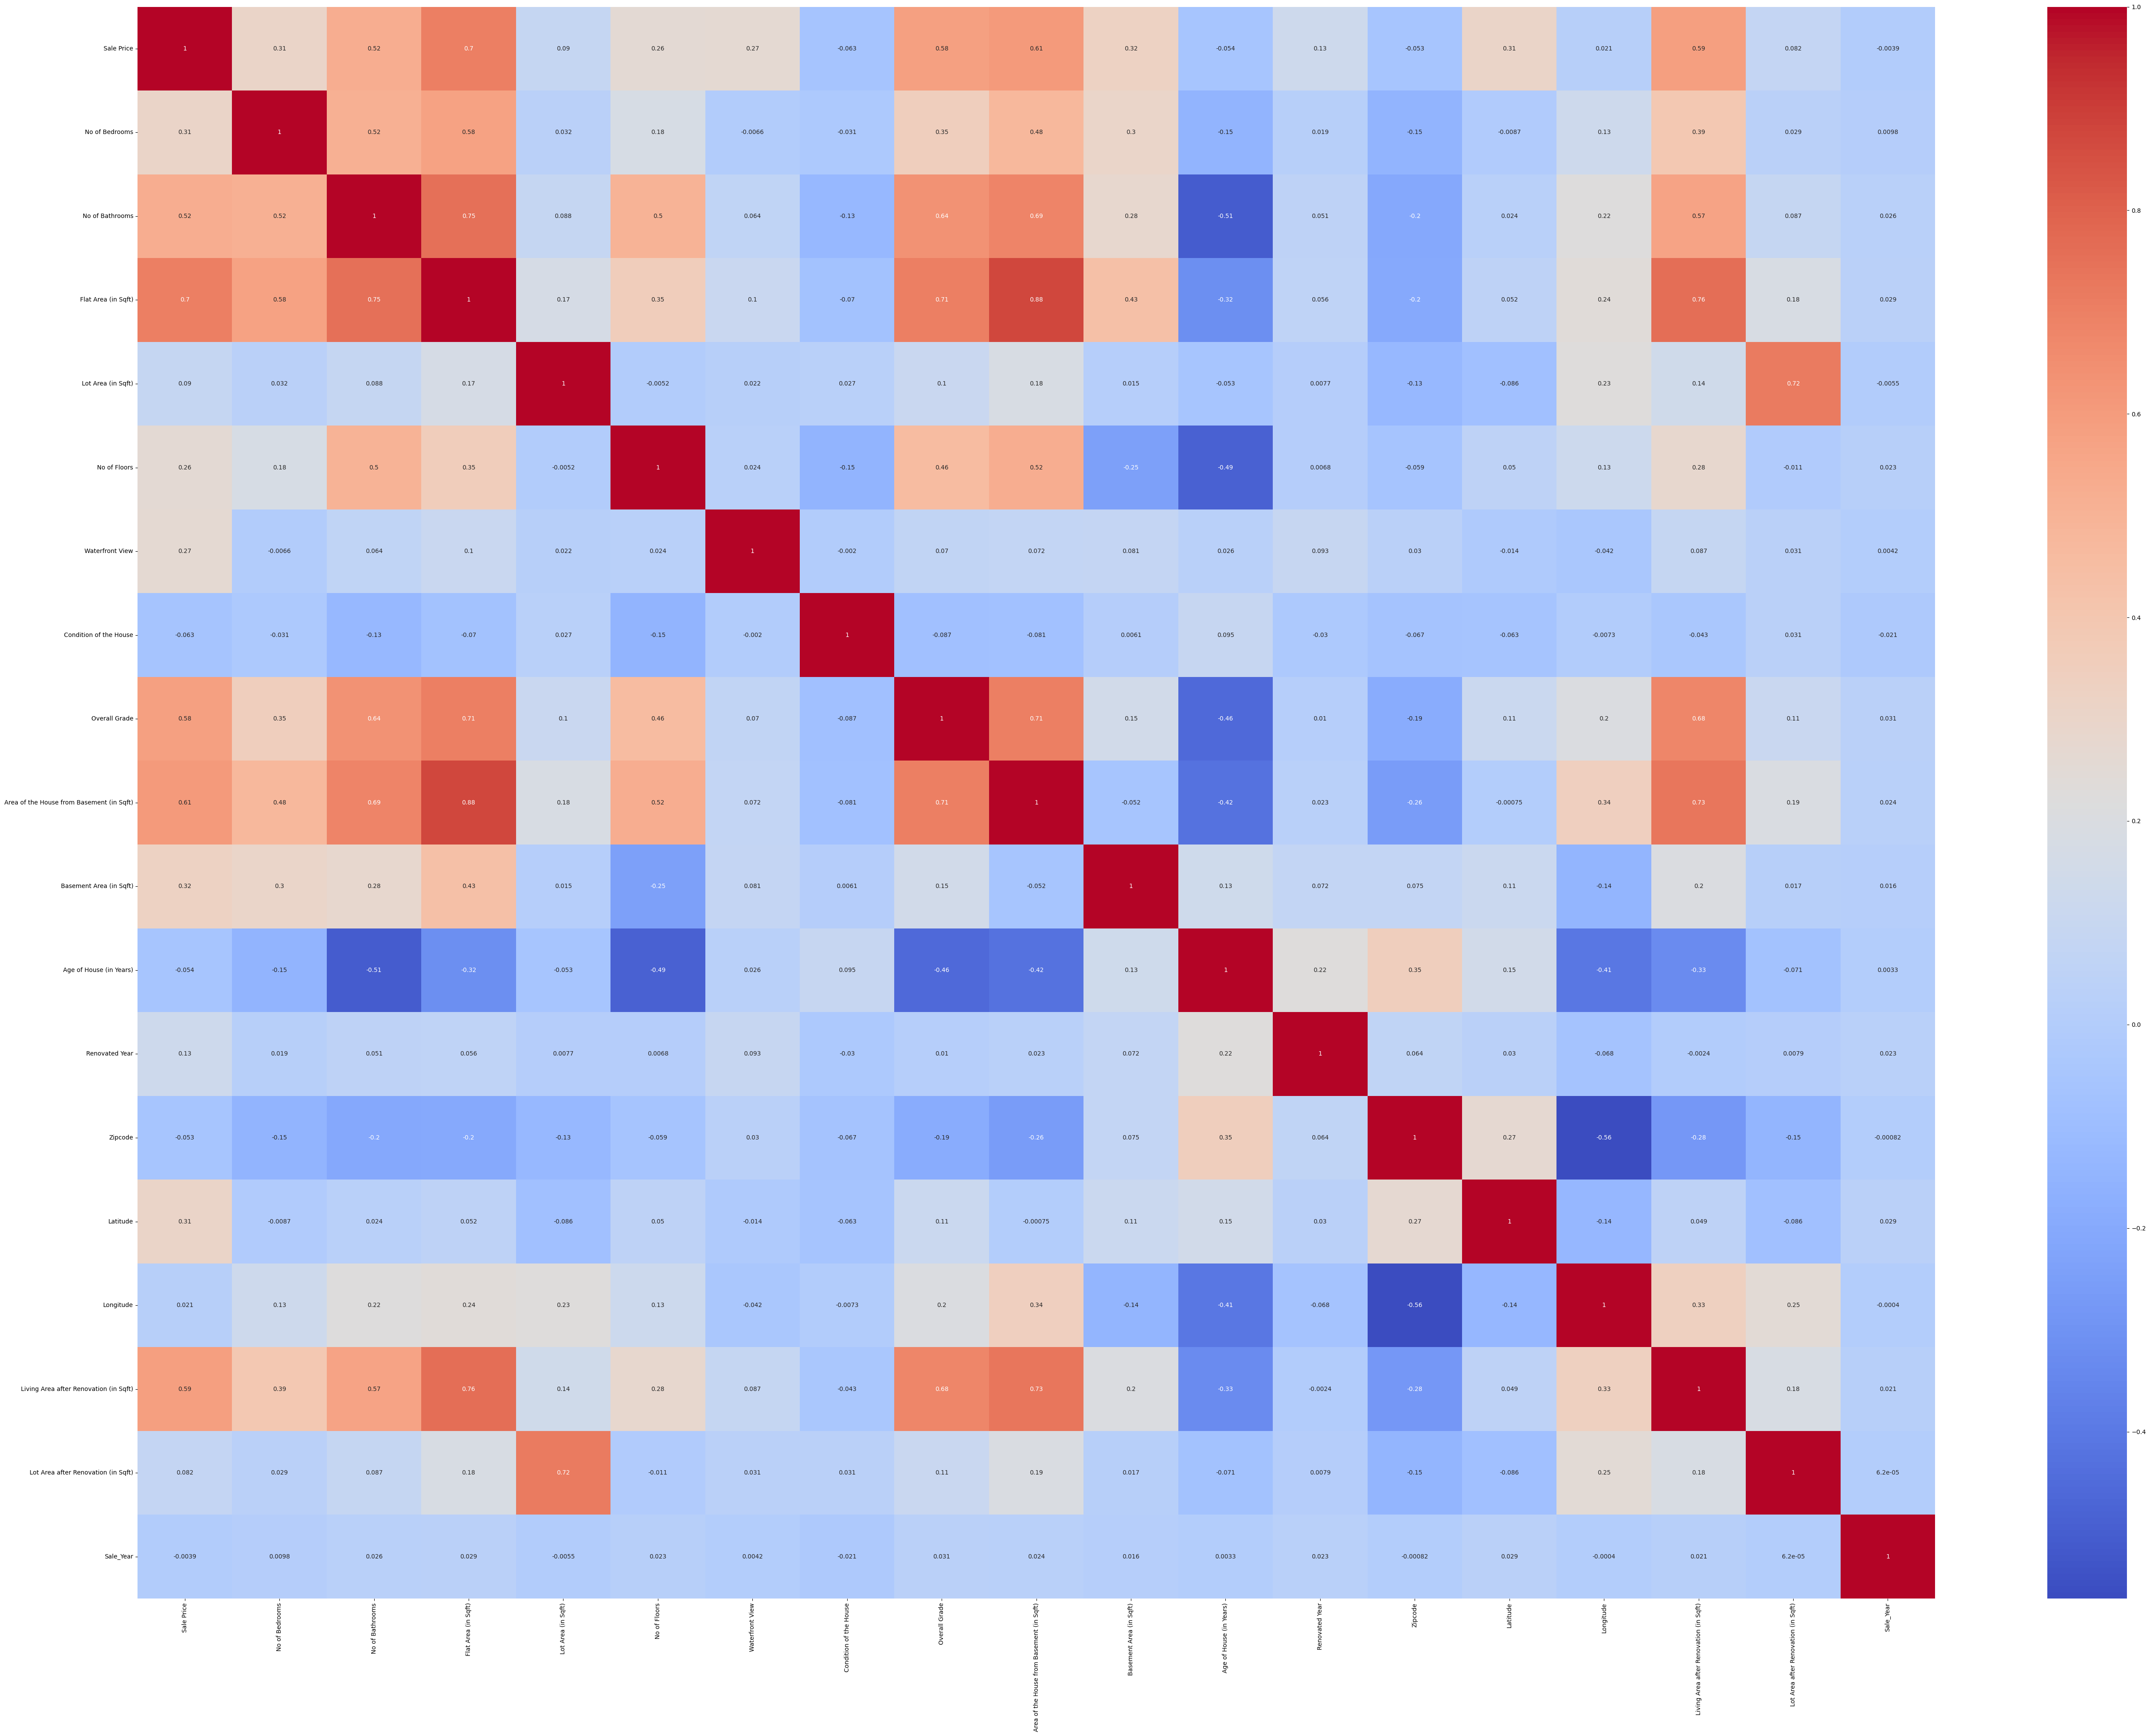

In [ ]:
corr_cat_result = df.corr()

plt.figure(figsize=(55,40))
sns.heatmap(corr_cat_result, cmap="coolwarm", annot=True )
plt.tight_layout()

# **OUTLIER** **TREATMENT**

In [ ]:
# List the few columns you WANT to keep
columns_to_keep = [
    'Sale Price',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Condition of the House',
    'Lot Area after Renovation (in Sqft)'
]
# Find all columns that are NOT in your keep list
columns_to_drop = [col for col in df.columns if col not in columns_to_keep]

# Drop all remaining columns in-place
df.drop(columns=columns_to_drop, inplace=True)

In [ ]:
df.head()

,Sale Price,Flat Area (in Sqft),Lot Area (in Sqft),Condition of the House,Lot Area after Renovation (in Sqft)
0,221900.0,1180.0,5650.0,2,5650
1,538000.0,2570.0,7242.0,2,7639
2,180000.0,770.0,10000.0,2,8062
3,604000.0,1960.0,5000.0,1,5000
4,510000.0,1680.0,8080.0,2,7503


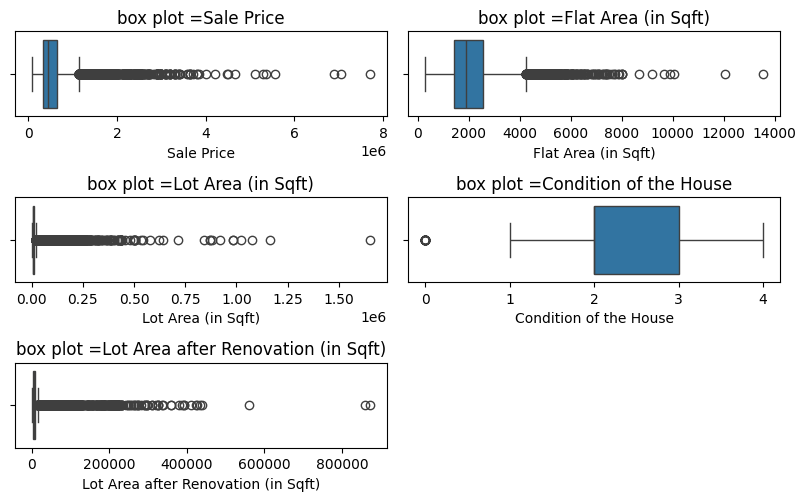

In [ ]:
columns=df.columns
plt.figure(figsize=(8,8))
for i,col in enumerate(columns):
    plt.subplot(len(columns),2,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"box plot ={col}")
plt.tight_layout()
plt.show()

In [ ]:
columns = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]

for col in columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    # Replace outliers with upper and lower boundary limits
    df[col] = df[col].clip(lower=lower, upper=upper)


In [ ]:
df[col]=df[col].clip(upper=upper,lower=lower)# to replace the value of outiler with the

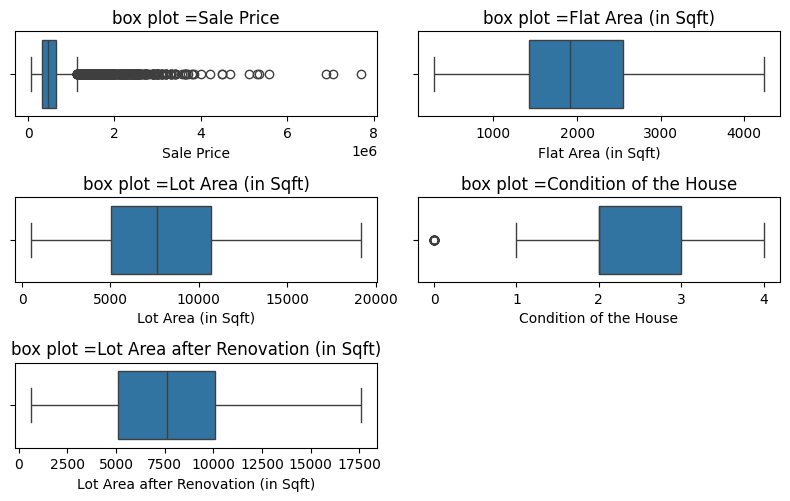

In [ ]:
columns=df.columns
plt.figure(figsize=(8,8))
for i,col in enumerate(columns):
    plt.subplot(len(columns),2,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"box plot ={col}")
plt.tight_layout()
plt.show()

In [ ]:
X =df.drop(columns=["Sale Price"])
y = df["Sale Price"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (17264, 4)
X_test shape:  (4316, 4)
y_train shape: (17264,)
y_test shape:  (4316,)


In [ ]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

In [ ]:
X_train.head()

,Flat Area (in Sqft),Lot Area (in Sqft),Condition of the House,Lot Area after Renovation (in Sqft)
8993,2340.0,19162.125,2,17567.5
21317,1680.0,977.000,2,977.0
12372,1120.0,2000.000,2,4000.0
6197,3320.0,5354.000,2,4040.0
20555,2560.0,5102.000,2,5059.0


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (17264, 4)
X_test shape:  (4316, 4)
y_train shape: (17264,)
y_test shape:  (4316,)


In [ ]:
scaler.fit(X_train,y_train)

StandardScaler()